# Organization-role composition by degree and RSA strength

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
DATA_PATH = ROOT / "data" / "synthetic_perlmutter_memberships_2020_2026.csv"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from artifact_utils import load_memberships, build_user_graph, node_scores, latest_roles, integer_log_bins, continuous_log_bins, assign_bins, role_assignments, category_composition, ROLE_ORDER


In [2]:
memberships = load_memberships(DATA_PATH)
graph, _ = build_user_graph(memberships)
scores = node_scores(graph)
roles = role_assignments(memberships, scores["user_id"])
present = set(roles["role"])
order = [role for role in ROLE_ORDER if role in present]
full_colors = dict(zip(ROLE_ORDER, [plt.get_cmap("Set3")(p) for p in np.linspace(0.05, 0.95, len(ROLE_ORDER))]))

positive_degree = scores.query("degree > 0").copy()
degree_edges, degree_labels = integer_log_bins(positive_degree["degree"], 24)
degree_binned = assign_bins(positive_degree, "degree", degree_edges, degree_labels)
degree_counts, degree_composition = category_composition(degree_binned, roles, "role", "weight", order)

positive_rsa = scores.query("rsa_strength > 0").copy()
rsa_edges, rsa_labels = continuous_log_bins(positive_rsa["rsa_strength"], 24)
rsa_binned = assign_bins(positive_rsa, "rsa_strength", rsa_edges, rsa_labels)
rsa_counts, rsa_composition = category_composition(rsa_binned, roles, "role", "weight", order)


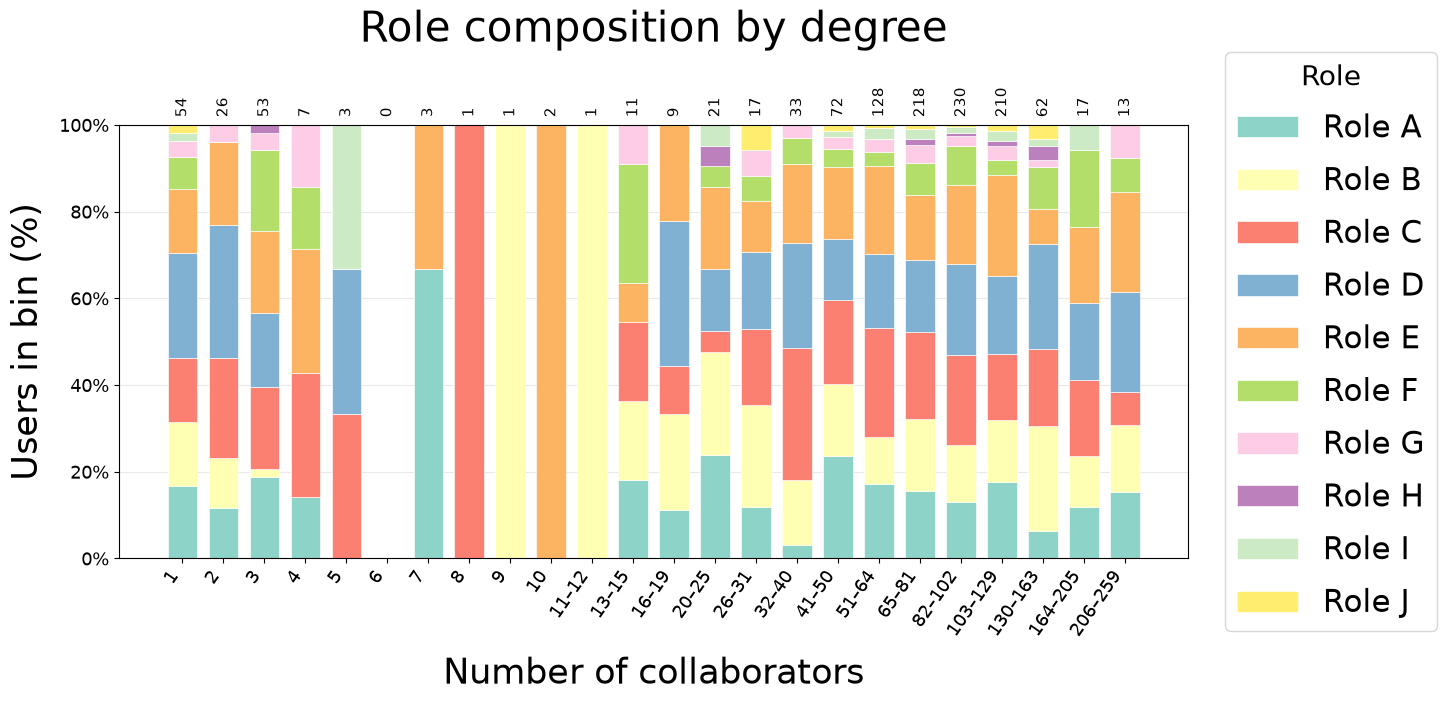

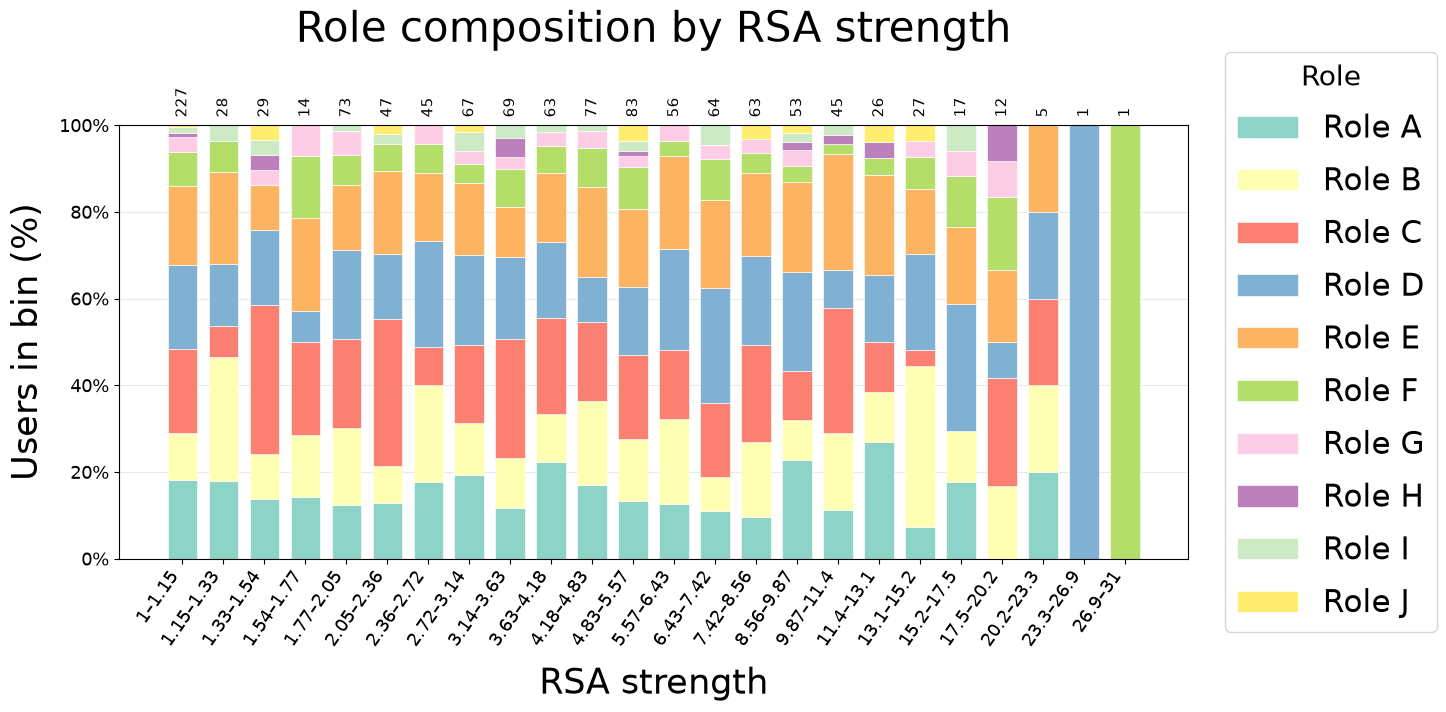

In [3]:
def plot_composition(composition, counts, title, x_label, filename):
    pivot = composition.pivot(index="bin_order", columns="role", values="percentage").reindex(columns=order).fillna(0)
    x = np.arange(len(counts))
    fig, ax = plt.subplots(figsize=(15.5, 8.5))
    bottom = np.zeros(len(counts))
    for role in order:
        values = pivot.reindex(x, fill_value=0)[role].to_numpy()
        ax.bar(x, values, bottom=bottom, width=0.72, label=role, color=full_colors[role], edgecolor="white", linewidth=0.45)
        bottom += values
    for position, count in zip(x, counts["n_unique_users"]):
        ax.text(position, 1.018, f"{int(count):,}", transform=ax.get_xaxis_transform(), ha="center", va="bottom", rotation=90, fontsize=11, clip_on=False)
    ax.set_title(title, fontsize=30, pad=60)
    ax.set_xlabel(x_label, fontsize=25, labelpad=12)
    ax.set_ylabel("Users in bin (%)", fontsize=25, labelpad=10)
    ax.set_xticks(x, counts["bin_label"], rotation=55, ha="right", fontsize=13)
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.tick_params(axis="y", labelsize=13)
    ax.grid(axis="y", alpha=0.28, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(title="Role", loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=22, title_fontsize=20, frameon=True, labelspacing=0.7)
    fig.subplots_adjust(left=0.10, right=0.79, top=0.81, bottom=0.30)
    fig.savefig(OUTPUT_DIR / filename, dpi=350, bbox_inches="tight")
    plt.show()

plot_composition(degree_composition, degree_counts, "Role composition by degree", "Number of collaborators", "role_composition_by_degree.png")
plot_composition(rsa_composition, rsa_counts, "Role composition by RSA strength", "RSA strength", "role_composition_by_rsa_strength.png")
